In [71]:
def get_A3SS_region(MATS_A3SS, include_flanking = False):
    """
    Given alternative 3' splice site data from MATS, identify the differentially spliced region and flanking sequences if desired

    Parameters
    ----------
    MATS_A3SS : pandas.DataFrame
        DataFrame containing alternative 3' splice site data from MATS
    include_flanking : bool, optional
        Whether to include flanking sequence columns (default is False)

    Returns
    -------
    pandas.DataFrame
        Updated DataFrame with event and flanking region information
    """
    #set the relevent start and end regions of the spliced out region, which are different depending on the strand
    region_start = []
    region_end = []
    first_flank_start = []
    first_flank_end = []
    second_flank_start = []
    second_flank_end = []

    #iterate through events and identify spliced region, which depends on DNA strand
    for i, row in MATS_A3SS.iterrows():
        strand = row['strand'] #check strand
        if strand == '+':
            region_start.append(row['longExonStart_0base'])
            region_end.append(row['shortES'])
            if include_flanking:
                second_flank_start.append(row['flankingES'])
                second_flank_end.append(row['flankingEE'])
                first_flank_start.append(row['shortES'])
                first_flank_end.append(row['shortEE'])
        else:
            region_start.append(row['shortEE'])
            region_end.append(row['longExonEnd'])
            if include_flanking:
                second_flank_start.append(row['flankingES'])
                second_flank_end.append(row['flankingEE'])
                first_flank_start.append(row['shortES'])
                first_flank_end.append(row['shortEE'])

    #save region info
    MATS_A3SS['event_start'] = region_start
    MATS_A3SS['event_end'] = region_end
    if include_flanking:
        MATS_A3SS['first_flank_start'] = first_flank_start
        MATS_A3SS['first_flank_end'] = first_flank_end
        MATS_A3SS['second_flank_start'] = second_flank_start
        MATS_A3SS['second_flank_end'] = second_flank_end
    return MATS_A3SS

# Load data

In [203]:
import pandas as pd

rbp = 'U2AF1'
rmats_folder =f'N:/Splicing/RBP_signaling/MATS_GencodeV29/shRNA/HepG2/{rbp}/'
event_type = 'SE'
junction_type = 'JCEC'

alpha = 0.05
min_dpsi = 0.2

data = pd.read_csv(f'{rmats_folder}{event_type}.MATS.{junction_type}.txt', sep='\t')
data = data[(data['FDR'] < alpha) & (abs(data['IncLevelDifference']) > min_dpsi)]

spliced_ptms = pd.read_csv(f'N:/Splicing/RBP_signaling/PTM-POSEv0.3/MATS_GencodeV29/HepG2/{rbp}/spliced_ptms.csv')

In [204]:
gene = 'CDK5'
data_sub = data[data['geneSymbol'] == gene].copy()

if data_sub.shape[0] == 0:
    print(f'No significant events for {gene}')
elif data_sub.shape[0] > 1:
    print(f'Multiple significant events for {gene}, showing event with highest psi change')
    data_sub = data_sub.loc[abs(data_sub['IncLevelDifference']).idxmax()]
else:
    print('One significant event found')

One significant event found


In [190]:
data_sub = get_A3SS_region(data_sub, include_flanking = True).squeeze()
chromosome = data_sub['chr']
strand = data_sub['strand']
spliced_region = (data_sub['event_start'], data_sub['event_end'])
upstream_region = (data_sub['first_flank_start'], data_sub['first_flank_end'])
downstream_region = (data_sub['second_flank_start'], data_sub['second_flank_end'])


In [205]:
#skipped exon
data_sub = data_sub.squeeze()
chromosome = data_sub['chr']
strand = data_sub['strand']
spliced_region = (data_sub['exonStart_0base'], data_sub['exonEnd'])
upstream_region = (data_sub['upstreamES'], data_sub['upstreamEE'])
downstream_region = (data_sub['downstreamES'], data_sub['downstreamEE'])

In [5]:
import sys
sys.path.append('..')
import plotting
import importlib
importlib.reload(plotting)

import sqlite3
mapper_db = sqlite3.connect('mapper.db')
plotter = plotting.plotter(mapper_db)

### Get canonical isoform data

In [146]:
gene

'CAMK2G'

In [210]:

canonical_isoform = plotter.get_canonical_isoform(gene, id_type = 'Name')
exons = plotter.get_exon_info(id = canonical_isoform, id_type = 'Isoform')

ENSE00003665172

In [211]:
pd.DataFrame(exons, columns = plotter.get_table_columns('transcript_exon'))

,Exon_stable_ID,Transcript_stable_ID,Constitutive_exon,Exon_rank_in_transcript,Transcript_start,Transcript_end,Protein_start,Protein_end
0,ENSE00001895936,ENST00000485972,0,1,0,86,0.000000,12.333333
1,ENSE00003626826,ENST00000485972,0,2,86,175,12.333333,42.000000
2,ENSE00003508423,ENST00000485972,0,3,175,243,42.000000,64.666667
3,ENSE00003532330,ENST00000485972,0,4,243,304,64.666667,85.000000
4,ENSE00003486655,ENST00000485972,0,5,304,361,85.000000,104.000000
5,ENSE00003665172,ENST00000485972,0,6,361,457,104.000000,136.000000
6,ENSE00003459627,ENST00000485972,0,7,457,532,136.000000,161.000000
7,ENSE00001088281,ENST00000485972,0,8,532,629,161.000000,193.333333
8,ENSE00001598399,ENST00000485972,0,9,629,699,193.333333,216.666667
9,ENSE00001621502,ENST00000485972,0,10,699,760,216.666667,237.000000


In [46]:
spliced_region

(139614412, 139614493)

In [11]:
query = """SELECT * FROM exons 
        WHERE Gene_stable_ID = ?"""
#query = """SELECT * FROM exons WHERE Gene_stable_ID = ?"""
exons = plotter.conn.execute(query, (id,)).fetchall()
exons

InterfaceError: Error binding parameter 0 - probably unsupported type.

### Find exons associated with event

In [207]:

start = spliced_region[0] + 1 + 1000
end = spliced_region[1] + 1000
id = plotter.get_gene_id(gene)

query = """SELECT * FROM exons 
        WHERE Gene_stable_ID = ?
        AND Gene_Start >= ?
        AND Gene_End <= ?"""
#query = """SELECT * FROM exons WHERE Gene_stable_ID = ?"""
exons = plotter.conn.execute(query, (id,int(start),int(end))).fetchall()
exons

[]

In [167]:
query = """SELECT * FROM transcript_exon WHERE Exon_stable_ID = ?"""
exons_in_trans = pd.DataFrame(plotter.conn.execute(query, (exons[0][0],)).fetchall(), columns = plotter.get_table_columns('transcript_exon'))
noncoding = exons_in_trans['Protein_start'].isnull().all()
noncoding

False

In [168]:
exons_in_trans

,Exon_stable_ID,Transcript_stable_ID,Constitutive_exon,Exon_rank_in_transcript,Transcript_start,Transcript_end,Protein_start,Protein_end
0,ENSE00001875629,ENST00000406875,0,1,0,394,0.0,6.333333


### Plot exon track (transcript level)

In [208]:
full_overlap = False

event_start = spliced_region[0] + 1 
event_end = spliced_region[1] 
id = plotter.get_gene_id(gene)
if full_overlap:
        start = spliced_region[0] + 1 
        end = spliced_region[1] 
        id = plotter.get_gene_id(gene)

        query = """SELECT * FROM exons 
                WHERE Gene_stable_ID = ?
                AND Gene_Start == ?
                AND Gene_End == ?"""
        #query = """SELECT * FROM exons WHERE Gene_stable_ID = ?"""
        exons = plotter.conn.execute(query, (id,int(event_start),int(event_end))).fetchall()
        spliced_exon = exons[0][0]
else:

        query = """SELECT * FROM exons 
        WHERE Gene_stable_ID = ?
        AND Gene_Start <= ?
        AND Gene_End >= ?"""
        exons = plotter.conn.execute(query, (id,int(event_start),int(event_end))).fetchall()
        spliced_exon = exons[0][0]



In [209]:
exons

[('ENSE00003665172', 'ENSG00000164885', 151055753, 151055848, 96)]

In [212]:
#transcript = 'ENST00000217244' #CSNK2A1
#transcript = 'ENST00000406875' #HIPK2
transcript = 'ENST00000485972' #CDK5
query = """SELECT * FROM transcript_exon
        LEFT JOIN exons ON transcript_exon.Exon_stable_ID = exons.Exon_stable_ID
        WHERE transcript_exon.Transcript_stable_ID = ?"""
exons = plotter.conn.execute(query, (transcript,)).fetchall()
columns = plotter.get_table_columns('transcript_exon') + plotter.get_table_columns('exons') 
exons_df = pd.DataFrame(exons, columns = columns)
#remove duplicate columns from the join
exons_df = exons_df.loc[:,~exons_df.columns.duplicated()]
exons_df.head()

,Exon_stable_ID,Transcript_stable_ID,Constitutive_exon,Exon_rank_in_transcript,Transcript_start,Transcript_end,Protein_start,Protein_end,Gene_stable_ID,Gene_Start,Gene_End,Exon_Length
0,ENSE00001895936,ENST00000485972,0,1,0,86,0.000000,12.333333,ENSG00000164885,151057812,151057897,86
1,ENSE00003626826,ENST00000485972,0,2,86,175,12.333333,42.000000,ENSG00000164885,151057072,151057160,89
2,ENSE00003508423,ENST00000485972,0,3,175,243,42.000000,64.666667,ENSG00000164885,151056908,151056975,68
3,ENSE00003532330,ENST00000485972,0,4,243,304,64.666667,85.000000,ENSG00000164885,151056736,151056796,61
4,ENSE00003486655,ENST00000485972,0,5,304,361,85.000000,104.000000,ENSG00000164885,151056580,151056636,57


In [213]:
if not full_overlap:
    #get transcript_coords of event
    exon_row = exons_df[exons_df['Exon_stable_ID'] == spliced_exon].squeeze()
    exon_start = exon_row['Gene_Start']
    exon_end = exon_row['Gene_End']
    event_start_offset = event_start - exon_start
    event_end_offset = exon_end - event_end

    #get transcript location
    if strand == '+':
        event_start_transcript = exon_row['Transcript_start'] + event_start_offset
        event_end_transcript = exon_row['Transcript_start'] + event_end_offset
    else:
        event_start_transcript = exon_row['Transcript_end'] - event_start_offset
        event_end_transcript = exon_row['Transcript_end'] - event_end_offset

In [214]:
transcript_info = plotter.conn.execute("""SELECT * FROM transcripts WHERE Transcript_stable_ID = ?""", (transcript,)).fetchone()
transcript_info = pd.Series(transcript_info, index = plotter.get_table_columns('transcripts'))
transcript_info

Transcript_stable_ID                              ENST00000485972
Gene_stable_ID                                    ENSG00000164885
APPRIS_annotation                                      principal1
Ensembl_Canonical                                             1.0
Transcript_support_level    tsl1 (assigned to previous version 5)
TRIFID_Score                                                  1.0
Relative_CDS_Start                                             49
Relative_CDS_Stop                                             928
Isoform_ID                                               Q00535-1
dtype: object

In [215]:
spliced_exon = ''

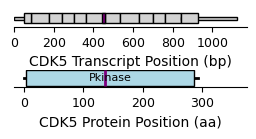

In [232]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
noncoding_color = 'lightgray'
coding_color = 'lightblue'

min_exon_rank = 1
max_exon_rank = 15
#trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]
trim_exons = exons_df.copy()

fig, axes = plt.subplots(figsize=(3, 1), nrows = 2)
fig.subplots_adjust(hspace = 2.5)

ax = axes[0]
for i, row in trim_exons.iterrows():
    #extract starting and end positions of exon
    start = row['Transcript_start']
    end = row['Transcript_end']

    #check if exon is fully noncoding, fully coding, or if cds start/stop exists in exon. Plot exon accordingly
    if row['Exon_stable_ID'][0] == spliced_exon:
        coding_color = 'green'
        noncoding_color = 'green'
        alpha = 0.5
    else:
        coding_color = 'lightgray'
        noncoding_color = 'lightgray'
        alpha = 1
    
    if end < transcript_info['Relative_CDS_Start'] or start > transcript_info['Relative_CDS_Stop']: #fully noncoding
        rect = patches.Rectangle((start,0.4), end - start, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    elif start >= transcript_info['Relative_CDS_Start'] and end <= transcript_info['Relative_CDS_Stop']: #fully coding
        rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((start,0.4), end - start, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(noncoding_rect)
        
        if start < transcript_info['Relative_CDS_Start']:
            start = transcript_info['Relative_CDS_Start']
        if end > transcript_info['Relative_CDS_Stop']:
            end = transcript_info['Relative_CDS_Stop']
        
        noncoding_rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3, alpha = alpha)
        ax.add_patch(noncoding_rect)

#add rectangle for spliced region
rect = patches.Rectangle((event_start_transcript,0.23), event_end_transcript - event_start_transcript-15, 0.55, facecolor = 'purple', edgecolor = 'black', zorder = 2, alpha = 1)
ax.add_patch(rect)
#ax.set_xlim(0, trim_exons['Transcript_end'].max() + 50)
#xlim_max = 4500
xlim_max = trim_exons['Transcript_end'].max() + 50
ax.set_xlim(0, xlim_max)
#ax.axhline(0.5, color = 'black', linestyle = '--', zorder = 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.tick_params(labelsize = 9)
ax.set_xlabel('CDK5 Transcript Position (bp)', fontsize = 10)


#plot domains
domains = plotter.get_domain_info(gene, id_type = 'Name')

#add protein line
cds_start = transcript_info['Relative_CDS_Start']
cds_end = transcript_info['Relative_CDS_Stop']
axes[1].set_xlim(-cds_start/3, (xlim_max - cds_start)/3)
axes[1].plot([0, (cds_end - cds_start)/3], [0.5, 0.5], color='black', linewidth=2)
for d in domains:
    domain_start = d[2]
    domain_end = d[3]
    domain_name = d[1]
    rect = patches.Rectangle((domain_start, 0.2), (domain_end - domain_start), 0.6, facecolor='lightblue', edgecolor='black', zorder=2)
    axes[1].add_patch(rect)
    axes[1].text((domain_start + domain_end)/2, 0.5, domain_name, ha='center', va='center', fontsize=8, zorder=4)
rect = patches.Rectangle(((event_start_transcript - cds_start)/3, 0.2), (event_end_transcript - event_start_transcript)/3, 0.6, color='purple', linewidth=2, zorder = 3)
axes[1].add_patch(rect)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].set_yticks([])
axes[1].tick_params(labelsize = 9)
axes[1].set_xlabel('CDK5 Protein Position (aa)', fontsize = 10)
plt.savefig('C:/Users/crowl/OneDrive/Documents/GradSchool/Research/Splicing/RBP_Paper/Figures/figure_panels/FigureS12_CSNK2A1/cdk5_transcript.png', dpi = 300, bbox_inches = 'tight')



In [226]:
(event_start_transcript - cds_start)/3

136.0

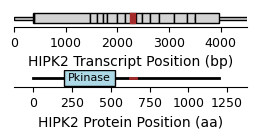

In [202]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
noncoding_color = 'lightgray'
coding_color = 'lightblue'

min_exon_rank = 1
max_exon_rank = 15
trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]
#trim_exons = exons_df.copy()

fig, axes = plt.subplots(figsize=(3, 1), nrows = 2)
fig.subplots_adjust(hspace = 2.5)

ax = axes[0]
for i, row in trim_exons.iterrows():
    #extract starting and end positions of exon
    start = row['Transcript_start']
    end = row['Transcript_end']

    #check if exon is fully noncoding, fully coding, or if cds start/stop exists in exon. Plot exon accordingly
    if row['Exon_stable_ID'][0] == spliced_exon:
        coding_color = 'green'
        noncoding_color = 'green'
        alpha = 0.5
    else:
        coding_color = 'lightgray'
        noncoding_color = 'lightgray'
        alpha = 1
    
    if end < transcript_info['Relative_CDS_Start'] or start > transcript_info['Relative_CDS_Stop']: #fully noncoding
        rect = patches.Rectangle((start,0.4), end - start, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    elif start >= transcript_info['Relative_CDS_Start'] and end <= transcript_info['Relative_CDS_Stop']: #fully coding
        rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((start,0.4), end - start, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(noncoding_rect)
        
        if start < transcript_info['Relative_CDS_Start']:
            start = transcript_info['Relative_CDS_Start']
        if end > transcript_info['Relative_CDS_Stop']:
            end = transcript_info['Relative_CDS_Stop']
        
        noncoding_rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3, alpha = alpha)
        ax.add_patch(noncoding_rect)

#add rectangle for spliced region
rect = patches.Rectangle((event_start_transcript,0.23), event_end_transcript - event_start_transcript-15, 0.55, facecolor = 'brown', edgecolor = 'brown', zorder = 2, alpha = 1)
ax.add_patch(rect)
#ax.set_xlim(0, trim_exons['Transcript_end'].max() + 50)
xlim_max = 4500
ax.set_xlim(0, xlim_max)
#ax.axhline(0.5, color = 'black', linestyle = '--', zorder = 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.tick_params(labelsize = 9)
ax.set_xlabel('HIPK2 Transcript Position (bp)', fontsize = 10)


#plot domains
domains = plotter.get_domain_info(gene, id_type = 'Name')

#add protein line
cds_start = transcript_info['Relative_CDS_Start']
cds_end = transcript_info['Relative_CDS_Stop']
axes[1].set_xlim(-cds_start/3, (xlim_max - cds_start)/3)
axes[1].plot([0, (cds_end - cds_start)/3], [0.5, 0.5], color='black', linewidth=2)
for d in domains:
    domain_start = d[2]
    domain_end = d[3]
    domain_name = d[1]
    rect = patches.Rectangle((domain_start, 0.2), (domain_end - domain_start), 0.6, facecolor='lightblue', edgecolor='black', zorder=2)
    axes[1].add_patch(rect)
    axes[1].text((domain_start + domain_end)/2, 0.5, domain_name, ha='center', va='center', fontsize=8, zorder=3)

axes[1].plot([(event_start_transcript - cds_start)/3, (event_end_transcript - cds_start)/3], [0.5, 0.5], color='brown', linewidth=2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].set_yticks([])
axes[1].tick_params(labelsize = 9)
axes[1].set_xlabel('HIPK2 Protein Position (aa)', fontsize = 10)
plt.savefig('C:/Users/crowl/OneDrive/Documents/GradSchool/Research/Splicing/RBP_Paper/Figures/figure_panels/FigureS12_CSNK2A1/hipk2_transcript.png', dpi = 300, bbox_inches = 'tight')



In [173]:
spliced_exon

'ENSE00001387136'

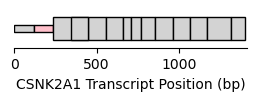

In [186]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
noncoding_color = 'lightgray'
coding_color = 'lightblue'

min_exon_rank = 1
max_exon_rank = 13
trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]
#trim_exons = exons_df.copy()

fig, ax = plt.subplots(figsize=(3, 0.5))


for i, row in trim_exons.iterrows():
    #extract starting and end positions of exon
    start = row['Transcript_start']
    end = row['Transcript_end']

    #check if exon is fully noncoding, fully coding, or if cds start/stop exists in exon. Plot exon accordingly
    if row['Exon_stable_ID'] == spliced_exon:
        coding_color = 'pink'
        noncoding_color = 'pink'
        alpha = 1
    else:
        coding_color = 'lightgray'
        noncoding_color = 'lightgray'
        alpha = 1
    
    if end < transcript_info['Relative_CDS_Start'] or start > transcript_info['Relative_CDS_Stop']: #fully noncoding
        rect = patches.Rectangle((start,0.4), end - start, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    elif start >= transcript_info['Relative_CDS_Start'] and end <= transcript_info['Relative_CDS_Stop']: #fully coding
        rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = noncoding_color, edgecolor = 'black', zorder = 2, alpha = alpha)
        ax.add_patch(noncoding_rect)
        
        if start < transcript_info['Relative_CDS_Start']:
            start = transcript_info['Relative_CDS_Start']
        if end > transcript_info['Relative_CDS_Stop']:
            end = transcript_info['Relative_CDS_Stop']
        
        noncoding_rect = patches.Rectangle((start,0.2), end - start, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3, alpha = alpha)
        ax.add_patch(noncoding_rect)

ax.set_xlim(0, trim_exons['Transcript_end'].max() + 10)
#ax.axhline(0.5, color = 'black', linestyle = '--', zorder = 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xlabel('CSNK2A1 Transcript Position (bp)')
#ax.axhline(1.5, color = 'black', linestyle = '-', zorder = 1, lw = 1)
#ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8, zorder = 2)
plt.savefig('C:/Users/crowl/OneDrive/Documents/GradSchool/Research/Splicing/RBP_Paper/Figures/figure_panels/FigureS12_CSNK2A1/csnk2a1_transcript.png', dpi = 300, bbox_inches = 'tight')

### Plot custom range transcript

In [150]:
data_sub['exonStart_0base']

142450465

In [16]:
transcript = 'ENST00000342645'
query = """SELECT * FROM transcript_exon
        LEFT JOIN exons ON transcript_exon.Exon_stable_ID = exons.Exon_stable_ID
        WHERE transcript_exon.Transcript_stable_ID = ?"""
exons = plotter.conn.execute(query, (transcript,)).fetchall()
columns = plotter.get_table_columns('transcript_exon') + plotter.get_table_columns('exons')
exons_df = pd.DataFrame(exons, columns = columns)
exons_df

,Exon_stable_ID,Transcript_stable_ID,Constitutive_exon,Exon_rank_in_transcript,Transcript_start,Transcript_end,Protein_start,Protein_end,Exon_stable_ID,Gene_stable_ID,Gene_Start,Gene_End,Exon_Length
0,ENSE00003743218,ENST00000342645,0,1,0,1082,0.000000,360.666667,ENSE00003743218,ENSG00000064393,139715932,139717013,1082
1,ENSE00001624166,ENST00000342645,1,2,1082,1206,360.666667,402.000000,ENSE00001624166,ENSG00000064393,139631602,139631725,124
2,ENSE00000833475,ENST00000342645,1,3,1206,1326,402.000000,442.000000,ENSE00000833475,ENSG00000064393,139631165,139631284,120
3,ENSE00000833477,ENST00000342645,1,4,1326,1413,442.000000,471.000000,ENSE00000833477,ENSG00000064393,139628953,139629039,87
4,ENSE00000833479,ENST00000342645,1,5,1413,1598,471.000000,532.666667,ENSE00000833479,ENSG00000064393,139626601,139626785,185
5,ENSE00000833481,ENST00000342645,1,6,1598,1761,532.666667,587.000000,ENSE00000833481,ENSG00000064393,139620401,139620563,163
6,ENSE00000833482,ENST00000342645,0,7,1761,1969,587.000000,656.333333,ENSE00000833482,ENSG00000064393,139614286,139614493,208
7,ENSE00000833485,ENST00000342645,1,8,1969,2091,656.333333,697.000000,ENSE00000833485,ENSG00000064393,139613202,139613323,122
8,ENSE00000833487,ENST00000342645,1,9,2091,2234,697.000000,744.666667,ENSE00000833487,ENSG00000064393,139604081,139604223,143
9,ENSE00001378553,ENST00000342645,0,10,2234,2396,744.666667,798.666667,ENSE00001378553,ENSG00000064393,139600435,139600596,162


In [50]:
#get gene info
query = """SELECT genes.* FROM genes 
            JOIN transcripts on transcripts.Gene_stable_ID = genes.Gene_stable_ID
            WHERE genes.Gene_stable_ID = ?"""
gene_info = plotter.conn.execute(query, (id,)).fetchone()
gene_info = dict(zip(plotter.get_table_columns('genes'), gene_info))
gene_info

{'Gene_stable_ID': 'ENSG00000064393',
 'Gene_name': 'HIPK2',
 'Strand': -1,
 'Chromosome': '7',
 'Gene_start': 139561570,
 'Gene_end': 139777998,
 'Number_of_Uniprot_Proteins': 1}

In [51]:
min_exon_rank = 6
max_exon_rank = 9
trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]

In [52]:
gene_cds_start, gene_cds_end = plotting.getGenomicCodingRegion(plotter, transcript, gene_info['Strand'])

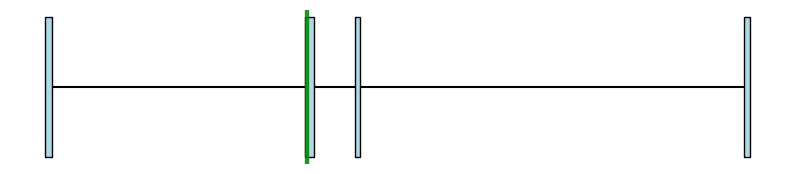

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
noncoding_color = 'lightgray'
coding_color = 'lightblue'

min_exon_rank = 6
max_exon_rank = 9
trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]

fig, ax = plt.subplots(figsize=(10, 2))
if gene_info['Strand'] == 1:
    ax.plot([trim_exons['Gene_Start'].min(), trim_exons['Gene_End'].max()], [0.5, 0.5], c = 'k')
else:
    ax.plot([trim_exons['Gene_End'].min(), trim_exons['Gene_Start'].max()], [0.5, 0.5], c = 'k')
for i, row in trim_exons.iterrows():
    #extract starting and end positions of exon
    fiveprime = row['Gene_Start']
    threeprime = row['Gene_End']

    #check if exon is fully noncoding, fully coding, or if cds start/stop exists in exon. Plot exon accordingly
    
    if threeprime < gene_cds_start or fiveprime > gene_cds_end: #fully noncoding
        rect = patches.Rectangle((fiveprime,0.4), threeprime - fiveprime, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(rect)
    elif fiveprime >= gene_cds_start and threeprime <= gene_cds_end: #fully coding
        rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(noncoding_rect)
        
        if fiveprime < gene_cds_start:
            fiveprime = gene_cds_start
        if threeprime > gene_cds_end:
            threeprime = gene_cds_end
        
        noncoding_rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3)
        ax.add_patch(noncoding_rect)

if gene_info['Strand'] == -1:
    ax.invert_xaxis()

ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8, zorder = 2)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
noncoding_color = 'lightgray'
coding_color = 'lightblue'

min_exon_rank = 6
max_exon_rank = 9
trim_exons = exons_df[(exons_df['Exon_rank_in_transcript'] >= min_exon_rank) & (exons_df['Exon_rank_in_transcript'] <= max_exon_rank)]

fig, ax = plt.subplots(figsize=(10, 2))
if gene_info['Strand'] == 1:
    ax.plot([trim_exons['Gene_Start'].min(), trim_exons['Gene_End'].max()], [0.5, 0.5], c = 'k')
else:
    ax.plot([trim_exons['Gene_End'].min(), trim_exons['Gene_Start'].max()], [0.5, 0.5], c = 'k')
for i, row in trim_exons.iterrows():
    #extract starting and end positions of exon
    fiveprime = row['Gene_Start']
    threeprime = row['Gene_End']

    #check if exon is fully noncoding, fully coding, or if cds start/stop exists in exon. Plot exon accordingly
    
    if threeprime < gene_cds_start or fiveprime > gene_cds_end: #fully noncoding
        rect = patches.Rectangle((fiveprime,0.4), threeprime - fiveprime, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(rect)
    elif fiveprime >= gene_cds_start and threeprime <= gene_cds_end: #fully coding
        rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax.add_patch(noncoding_rect)
        
        if fiveprime < gene_cds_start:
            fiveprime = gene_cds_start
        if threeprime > gene_cds_end:
            threeprime = gene_cds_end
        
        noncoding_rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3)
        ax.add_patch(noncoding_rect)

if gene_info['Strand'] == -1:
    ax.invert_xaxis()

ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8, zorder = 2)

In [113]:
gene_cds_end

508551

In [112]:
fiveprime

527933

True


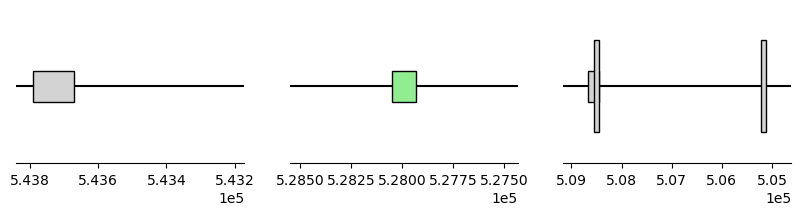

In [137]:
noncoding_color = 'lightgray'
coding_color = 'lightgrey'

fig, ax = plt.subplots(figsize=(10, 2), ncols = 3)
fig.subplots_adjust(wspace=0.2)

fiveprime = trim_exons.iloc[0]['Gene_Start']
threeprime = trim_exons.iloc[0]['Gene_End']
rect = patches.Rectangle((fiveprime,0.4), threeprime - fiveprime, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
ax[0].add_patch(rect)
ax[0].set_xlim(fiveprime - 500, threeprime +50)
ax[0].axhline(0.5, color = 'k', zorder = 1)
ax[0].set_yticks([])
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].invert_xaxis()

fiveprime = trim_exons.iloc[1]['Gene_Start']
threeprime = trim_exons.iloc[1]['Gene_End']
rect = patches.Rectangle((fiveprime,0.4), threeprime - fiveprime, 0.2, facecolor = 'lightgreen', edgecolor = 'black', zorder = 2)
ax[1].add_patch(rect)
ax[1].set_xlim(fiveprime - 500, threeprime +500)
ax[1].axhline(0.5, color = 'k', zorder = 1)
ax[1].spines['left'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_yticks([])
ax[1].invert_xaxis()


for i, row in trim_exons.iloc[2:4].iterrows():
    threeprime = row['Gene_End']
    fiveprime = row['Gene_Start']
    if threeprime < gene_cds_start or fiveprime > gene_cds_end: #fully noncoding
        print('True')
        rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax[2].add_patch(rect)
    elif fiveprime >= gene_cds_start and threeprime <= gene_cds_end: #fully coding
        print('True')
        rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 2)
        ax[2].add_patch(rect)
    else:#partially coding
        noncoding_rect = patches.Rectangle((fiveprime,0.4), threeprime - fiveprime, 0.2, facecolor = noncoding_color, edgecolor = 'black', zorder = 2)
        ax[2].add_patch(noncoding_rect)
        
        if fiveprime < gene_cds_start:
            fiveprime = gene_cds_start
        if threeprime > gene_cds_end:
            threeprime = gene_cds_end
        
        noncoding_rect = patches.Rectangle((fiveprime,0.2), threeprime - fiveprime, 0.6, facecolor = coding_color, edgecolor = 'black', zorder = 3)
        ax[2].add_patch(noncoding_rect)
ax[2].set_xlim(trim_exons.iloc[2:4]['Gene_Start'].min()-500, trim_exons.iloc[2:4]['Gene_End'].max() + 500)
ax[2].invert_xaxis()
ax[2].set_yticks([])
ax[2].axhline(0.5, color = 'k', zorder = 1)
ax[2].spines['left'].set_visible(False)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
#change to scientific notation with 2 significant digits
ax[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0) )

ax[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))

In [ ]:
def plot_single_transcript(mapper_db, tid, gene_start, gene_end, strand, ax):
    pass

### Plot

In [84]:
plotter.plot_canonical_isoform(text_id=gene)

In [163]:
spliced_region

(142450465, 142450602)

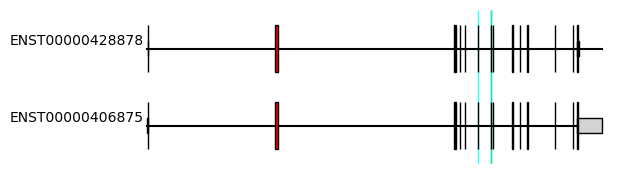

In [81]:

ax = plotter.plot_transcripts(data_sub['geneSymbol'], functional_threshold = 0.5)
ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8)
ax.axvspan(upstream_region[0], upstream_region[1], color='cyan', alpha=0.8)
ax.axvspan(downstream_region[0], downstream_region[1], color='cyan', alpha=0.8)

### Plot transcripts with coding sequence region highlighted

In [57]:
(spliced_region[0] - spliced_region[1])/3

-27.0

In [180]:
data_sub['IncLevelDifference']

0.381

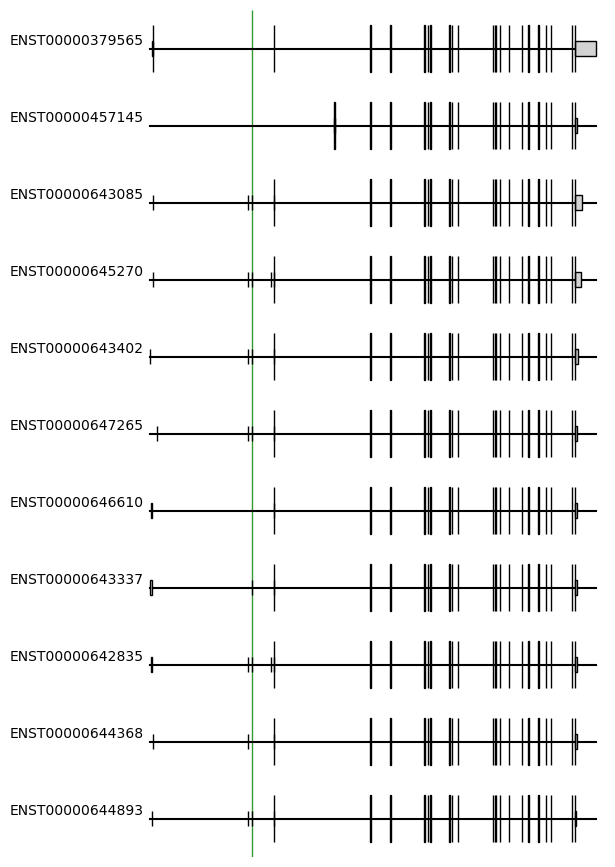

In [184]:

ax = plotter.plot_transcripts(data_sub['geneSymbol'], functional_threshold = 0.5)
ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8)
#ax.axvspan(upstream_region[0], upstream_region[1], color='cyan', alpha=0.8)
#ax.axvspan(downstream_region[0], downstream_region[1], color='cyan', alpha=0.8)

## Plot splice event

In [85]:
plotter.plot_splice_event(data_sub, event_type = 'SE')